# 可视化shap对应的raw data特点

In [1]:
import copy
import os
import random
import torch.nn as nn
from sklearn.model_selection import train_test_split
import torch
import pickle
from torch import optim
from torch.utils.data import DataLoader
import numpy as np

from deepview.calculate_results.models.utils import (
    find_majority_minority,
    data_loader_umineko,
    AE_eval_time_series,
    majority_value,
    sliding_window,
    read_sensor_data,
    process_acc,
    process_acc_press,
    process_acc_temperature,
    process_acc_gyr,
    process_acc_gps,
    process_press_temperature,
    process_gps
)
# from deepview.calculate_results.data.umineko.train_func import (
#     train_model,
#     evaluate_model,
#     evaluate_supContrast_model,
#     plot_confusion_matrix,
#     unfreeze_encoders,
#     freeze_encoders,
#     unfreeze_all,
# )
# from deepview.calculate_results.data.umineko.model_func import (
#     SimpleNN_1s,
#     SimpleNN_13s,
#     SimpleNN_11s,
#     SimpleNN_33s,
#     SimpleNN_32s,
#     ContrastiveLoss,
#     SupContrastiveLoss,
# )
# from deepview.calculate_results.data.umineko.active_utils import (
#     data_sampling
# )
# from deepview.calculate_results.data.umineko.cluster_method import (
#     vis_scatter_label_2d,
#     # plot_func
# )

def set_random_seed(seed):
    # Set seed for Python's random module
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

In [80]:
seed_value = 1
sampling_method = 'entropy'
sensor_type = 'AccelGyro'
# sensor_type = 'AccelGPS'

set_random_seed(seed_value)

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

SupCount = 1  # supcontrastive learning
# warmup = 0  # warmup epoch of supcontrastive learning
warmup = 20  # warmup epoch of supcontrastive learning
name_label = '_%s_Contrast%s_warm%s_seed%s'%(
    sampling_method, str(SupCount), str(warmup), str(seed_value))

print(name_label)
len_sw = 50

# ======= 1. 数据生成 ======= #
# if os.path.exists(sensor_type+'_data.pkl'):
#     with open(sensor_type+'_data.pkl', 'rb') as file:  # 'rb'表示以二进制读取模式打开文件
#         d_dict = pickle.load(file)
#         data_b = d_dict['data']
#         label_b = d_dict['label']
# else:
all_df = read_sensor_data()
selected_df = all_df[all_df.label_id != -2]
columns = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'label_id']

# if (sensor_type == 'Accel'):
#     columns = ['acc_x', 'acc_y', 'acc_z', 'label_id']
#     selected_np = process_acc(selected_df, columns)
# elif (sensor_type == 'AccelPress'):
#     columns = ['acc_x', 'acc_y', 'acc_z', 'pressure', 'label_id']
#     selected_np = process_acc_press(selected_df, columns)
# elif (sensor_type == 'AccelTemp'):
#     columns = ['acc_x', 'acc_y', 'acc_z', 'temperature', 'label_id']
#     selected_np = process_acc_temperature(selected_df, columns)
# elif (sensor_type == 'AccelGyro'):
#     columns = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'label_id']
#     selected_np = process_acc_gyr(selected_df, columns)
# elif (sensor_type == 'PressTemp'):
#     columns = ['pressure', 'temperature', 'label_id']
#     selected_np = process_press_temperature(selected_df, columns)
# elif (sensor_type == 'AccelGPS'):
#     columns = ['acc_x', 'acc_y', 'acc_z', 'latitude', 'longitude', 'label_id']
#     selected_np = process_acc_gps(selected_df, columns)
# else:
#     print('no model available')
# 
# tmp_b = sliding_window(selected_np, len_sw, len_sw)
# # concatenate list
# data_b = np.transpose(tmp_b[:, :, :-1], (0, 2, 1))  # [B, Len, dim-1] -> [B, dim-1, Len]
# label_b = tmp_b[:, :, -1]  # [B, Len]

    # # 将数据保存到文件
    # with open(sensor_type+'_data.pkl', 'wb') as file:  # 'wb'表示以二进制写入模式打开文件
    #     pickle.dump({'data': data_b, 'label': label_b}, file)

# majority_label, minority_label = find_majority_minority(label_b)
# # 将数据分为8:2，其中2为测试集
# vote_label = majority_value(label_b)
# X_train_full, X_test, y_train_full, y_test = (
#                           train_test_split(data_b, label_b,
#                           test_size=0.2, stratify=vote_label,
#                           # random_state=42
#                                            ))
# 
# # 从X_train_full中随机选择1%的数据作为X_labeled，其余为X_unlabeled
# X_labeled, X_unlabeled, y_labeled, y_unlabeled = (
#                             train_test_split(X_train_full,
#                                              y_train_full,
#                                              test_size=0.99,
#                                              # random_state=42
#                                              ))

_entropy_Contrast1_warm20_seed1


D:\code\DeepView\deepview\calculate_results\models\utils.py:157: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fill_selected_df = selected_df.fillna(method='ffill').fillna(method='bfill')  # pressure has nan values


In [119]:
selected_np = selected_df[columns].values
tmp_b = sliding_window(selected_np, len_sw, len_sw)
# concatenate list
data_b = np.transpose(tmp_b[:, :, :-1], (0, 2, 1))  # [B, Len, dim-1] -> [B, dim-1, Len]
label_b = tmp_b[:, :, -1]  # [B, Len]

In [120]:
major_label = majority_value(label_b)
major_label.shape

(7429,)

In [121]:
bath_label_idx = np.where(major_label == 2)[0]

In [122]:
bath_data = data_b[bath_label_idx, :, :]
bath_data.shape

(477, 6, 50)

In [123]:
bath_data_flat = np.concatenate(bath_data.transpose(0,2,1), axis=0)
bath_data_flat.shape

(23850, 6)

In [90]:
import matplotlib.pyplot as plt

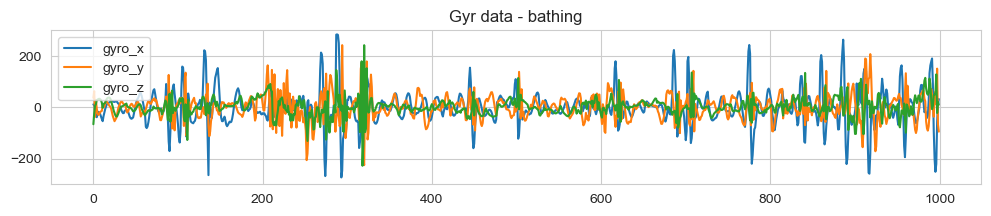

In [146]:
start = 2500
end = 3500
plt.figure(figsize=(12,2))
plt.plot(np.arange(end-start), bath_data_flat[start:end, 3], label='gyro_x')
plt.plot(np.arange(end-start), bath_data_flat[start:end, 4], label='gyro_y')
plt.plot(np.arange(end-start), bath_data_flat[start:end, 5], label='gyro_z')
plt.title('Gyr data - bathing')
plt.ylim(-300, 300)  # 限制Y轴范围
plt.legend()
plt.show()

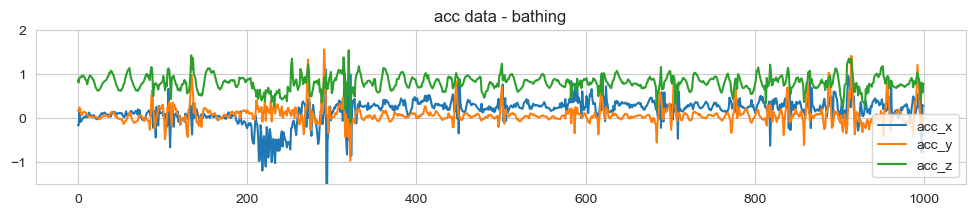

In [147]:
plt.figure(figsize=(12,2))
plt.plot(np.arange(end-start), bath_data_flat[start:end, 0], label='acc_x')
plt.plot(np.arange(end-start), bath_data_flat[start:end, 1], label='acc_y')
plt.plot(np.arange(end-start), bath_data_flat[start:end, 2], label='acc_z')
plt.title('acc data - bathing')
plt.ylim(-1.5, 2)  # 限制Y轴范围
plt.legend()
plt.show()

In [148]:
flypass_label_idx = np.where(major_label == 4)[0]
flypass_data = data_b[flypass_label_idx, :, :]
# bath_data.shape
flypass_data_flat = np.concatenate(flypass_data.transpose(0,2,1), axis=0)
# bath_data_flat.shape

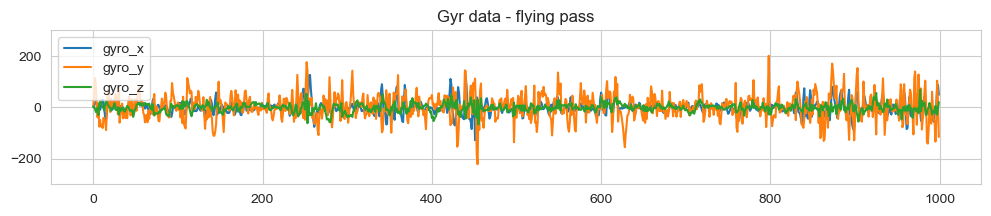

In [149]:
plt.figure(figsize=(12,2))
plt.plot(np.arange(end-start), flypass_data_flat[start:end, 3], label='gyro_x')
plt.plot(np.arange(end-start), flypass_data_flat[start:end, 4], label='gyro_y')
plt.plot(np.arange(end-start), flypass_data_flat[start:end, 5], label='gyro_z')
plt.title('Gyr data - flying pass')
plt.ylim(-300, 300)   # 限制Y轴范围
plt.legend()
plt.show()

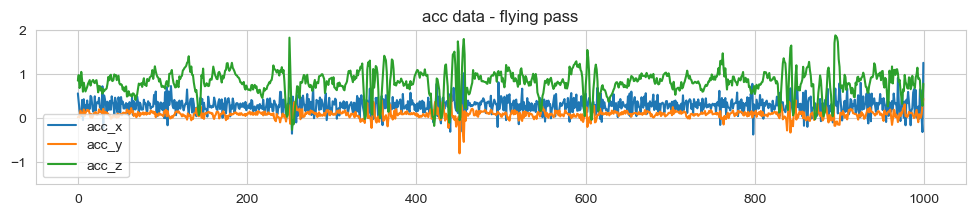

In [150]:
plt.figure(figsize=(12,2))
plt.plot(np.arange(end-start), flypass_data_flat[start:end, 0], label='acc_x')
plt.plot(np.arange(end-start), flypass_data_flat[start:end, 1], label='acc_y')
plt.plot(np.arange(end-start), flypass_data_flat[start:end, 2], label='acc_z')
plt.title('acc data - flying pass')
plt.ylim(-1.5, 2)  # 限制Y轴范围
plt.legend()
plt.show()

### gps data

In [151]:
from deepview.calculate_results.models.utils import (
    process_gps
)

In [165]:
# selected_df = all_df[all_df.label_id != -2]
columns = ['timestamp', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'latitude', 'longitude', 'label_id']
# process_acc_gps(selected_df, columns)
selected_df_new = all_df[columns].copy()
selected_df_new2, gps_len = process_gps(selected_df_new)
selected_df_new2 = selected_df_new2.fillna(method='ffill').fillna(method='bfill')
selected_df_new2 = selected_df_new2[selected_df_new2.label_id != -2]
selected_df_new2.head(5)

D:\code\DeepView\deepview\calculate_results\models\utils.py:647: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # Calculate differences, handling NaN by filling with zeros
D:\code\DeepView\deepview\calculate_results\models\utils.py:648: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non_nan['lat_diff'] = np.radians(df_non_nan['latitude'].diff())
D:\code\DeepView\deepview\calculate_results\models\utils.py:651: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

,timestamp,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,latitude,longitude,label_id,GPS_velocity,GPS_bearing
20939,2018-05-25T01:16:04.560Z,0.249023,-0.009277,0.833008,-1.602173,1.571655,-0.320435,40.538536,141.557495,0.0,0.118157,64.945273
20940,2018-05-25T01:16:04.600Z,0.238281,-0.005859,0.821777,-1.602173,1.892090,-0.534058,40.538536,141.557495,0.0,0.118157,64.945273
20941,2018-05-25T01:16:04.640Z,0.244141,-0.002441,0.823242,-1.846313,1.525879,-0.350952,40.538536,141.557495,0.0,0.118157,64.945273
20942,2018-05-25T01:16:04.680Z,0.241699,-0.001953,0.823730,-1.647949,1.632690,-0.473022,40.538536,141.557495,0.0,0.118157,64.945273
20943,2018-05-25T01:16:04.720Z,0.243652,-0.002930,0.831055,-1.663208,1.754761,-0.473022,40.538536,141.557495,0.0,0.118157,64.945273


In [166]:
selected_df_new2.GPS_bearing.unique()

array([ 64.94527333, 242.75629641,  63.01899764,   0.        ,
        51.11436625, 236.65823182, 102.88973089,  89.99996035,
       234.33178475,  89.99994053, 252.07010194,  15.42633617,
       259.54851863, 199.32859897, 223.53001785, 163.30139885,
       270.00001495, 225.46769495, 304.18219673, 131.91506332,
        89.99998018, 261.41332115, 329.03727059,  85.0951144 ,
        99.84379745, 327.05103307, 241.19506151, 106.54789611,
       323.3775232 , 303.14070543, 207.21194772,  94.92658245,
       280.34914034, 351.65866467, 181.13462327, 246.77535473,
       205.06425149,  69.60138788, 284.74413717,  63.15628927,
       109.04154711, 237.81713001, 329.03729638, 250.95843075,
       289.3355661 ,  68.86622857, 271.54688997, 156.04188973,
        99.59025265,  90.69319735,  51.66827658,  54.39122275,
        32.74303959,  54.48620689,  52.87411784, 225.58431059,
       254.69655481,  89.11036042,  87.7146456 ,  85.02331151,
        75.87560465,  89.47408118,  19.81168108,  30.31

In [179]:
columns = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'GPS_velocity', 'GPS_bearing', 'label_id']
selected_np = selected_df_new2[columns]
tmp_b = sliding_window(selected_np, len_sw, len_sw)
# concatenate list
data_b = np.transpose(tmp_b[:, :, :-1], (0, 2, 1))  # [B, Len, dim-1] -> [B, dim-1, Len]
label_b = tmp_b[:, :, -1]  # [B, Len]

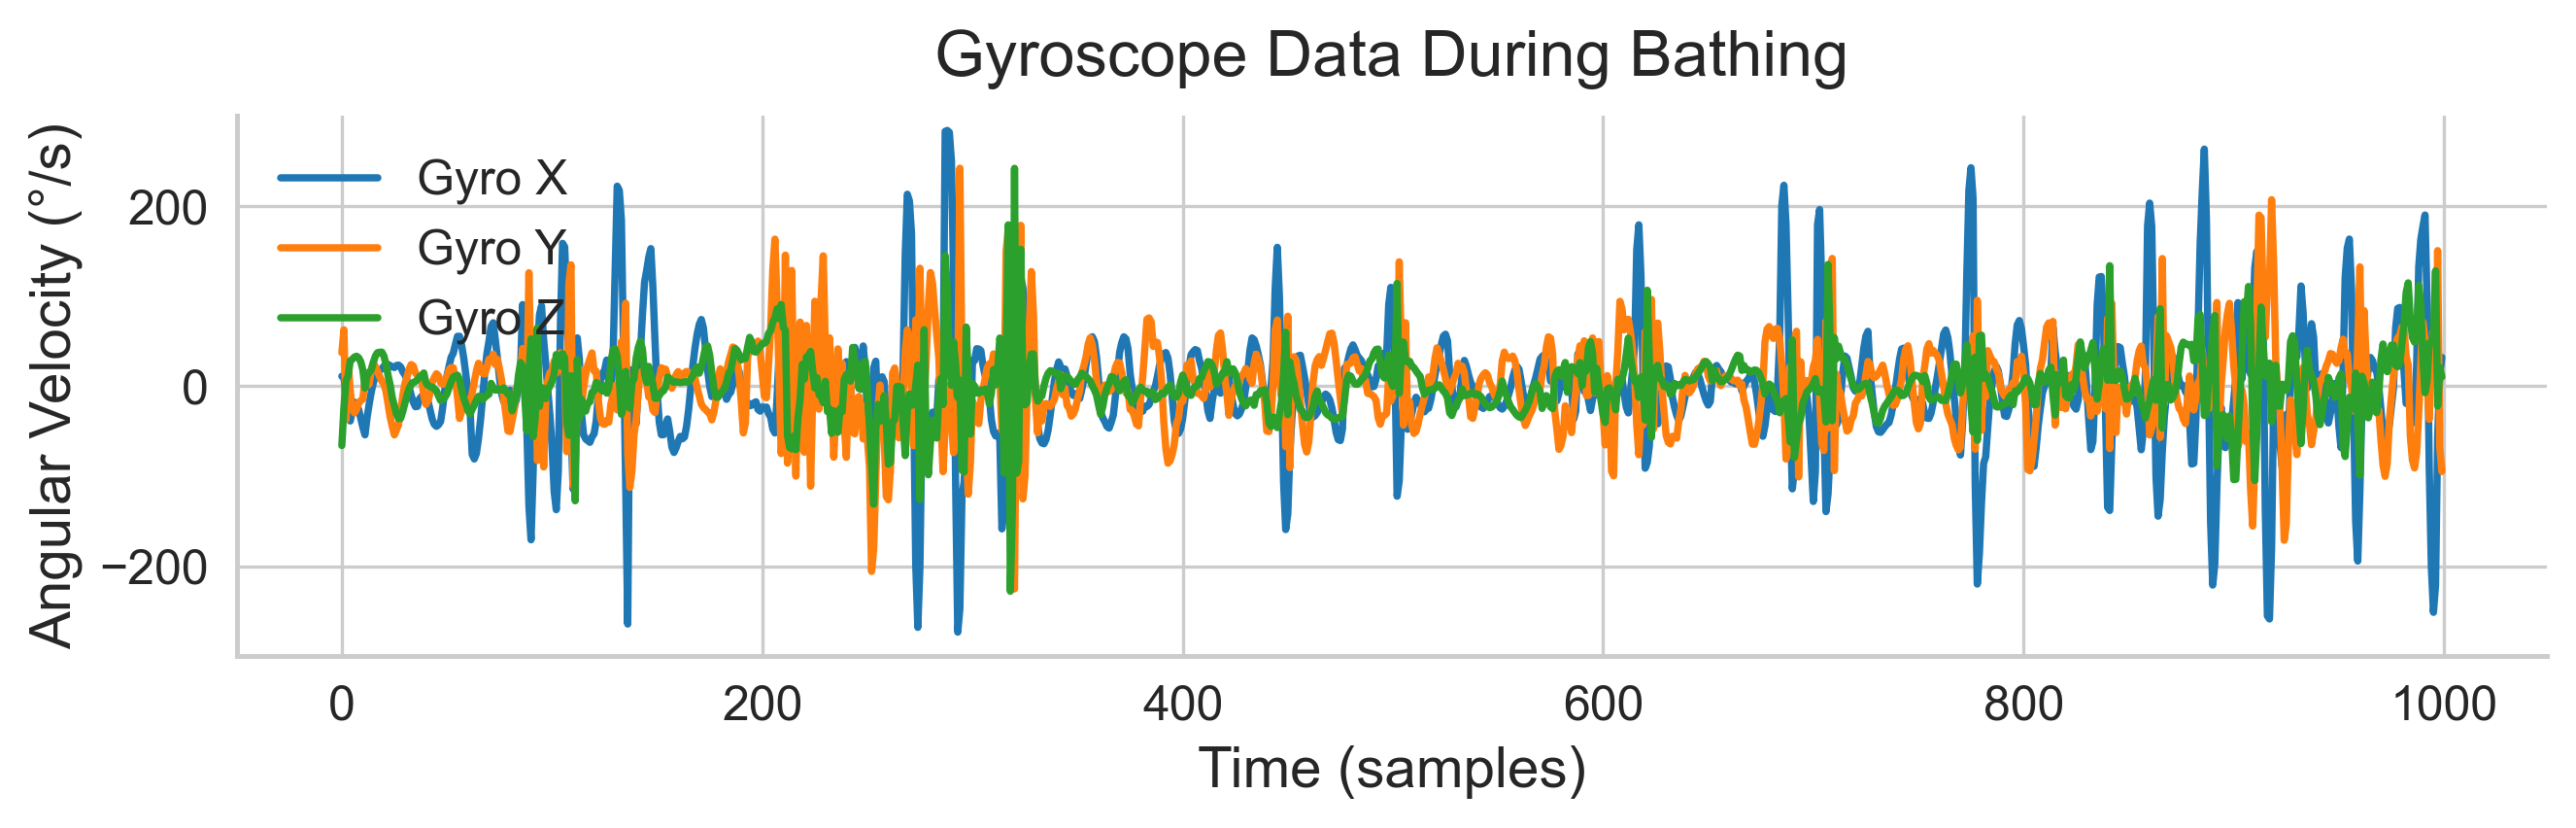

In [216]:
major_label = majority_value(label_b)
bath_label_idx = np.where(major_label == 2)[0]
bath_data = data_b[bath_label_idx, :, :]
bath_data_flat = np.concatenate(bath_data.transpose(0,2,1), axis=0)
start = 2500
end = 3500

# 设置全局样式
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],  # Nature 常用字体
    "font.size": 12,
    "axes.linewidth": 1.2,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# 开始绘图
fig, ax = plt.subplots(figsize=(9, 3), dpi=300)

time_range = np.arange(end - start)

# 绘制三条陀螺仪数据曲线，设置线宽和颜色
ax.plot(time_range, bath_data_flat[start:end, 3], label='Gyro X', linewidth=1.8, color='#1f77b4')
ax.plot(time_range, bath_data_flat[start:end, 4], label='Gyro Y', linewidth=1.8, color='#ff7f0e')
ax.plot(time_range, bath_data_flat[start:end, 5], label='Gyro Z', linewidth=1.8, color='#2ca02c')

# 设置标题和坐标轴
ax.set_title('Gyroscope Data During Bathing', pad=10)
ax.set_ylabel('Angular Velocity (°/s)')
ax.set_xlabel('Time (samples)')
ax.set_ylim(-300, 300)

# 图例放置在右上角外部
ax.legend(loc='upper left', frameon=False)

# 去除顶部和右侧边框，使图更简洁
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置背景为白色（默认）
ax.set_facecolor('white')

# 保存为矢量图格式（可选）
# plt.savefig('gyro_bathing.svg', format='svg', bbox_inches='tight')

plt.tight_layout()
plt.show()

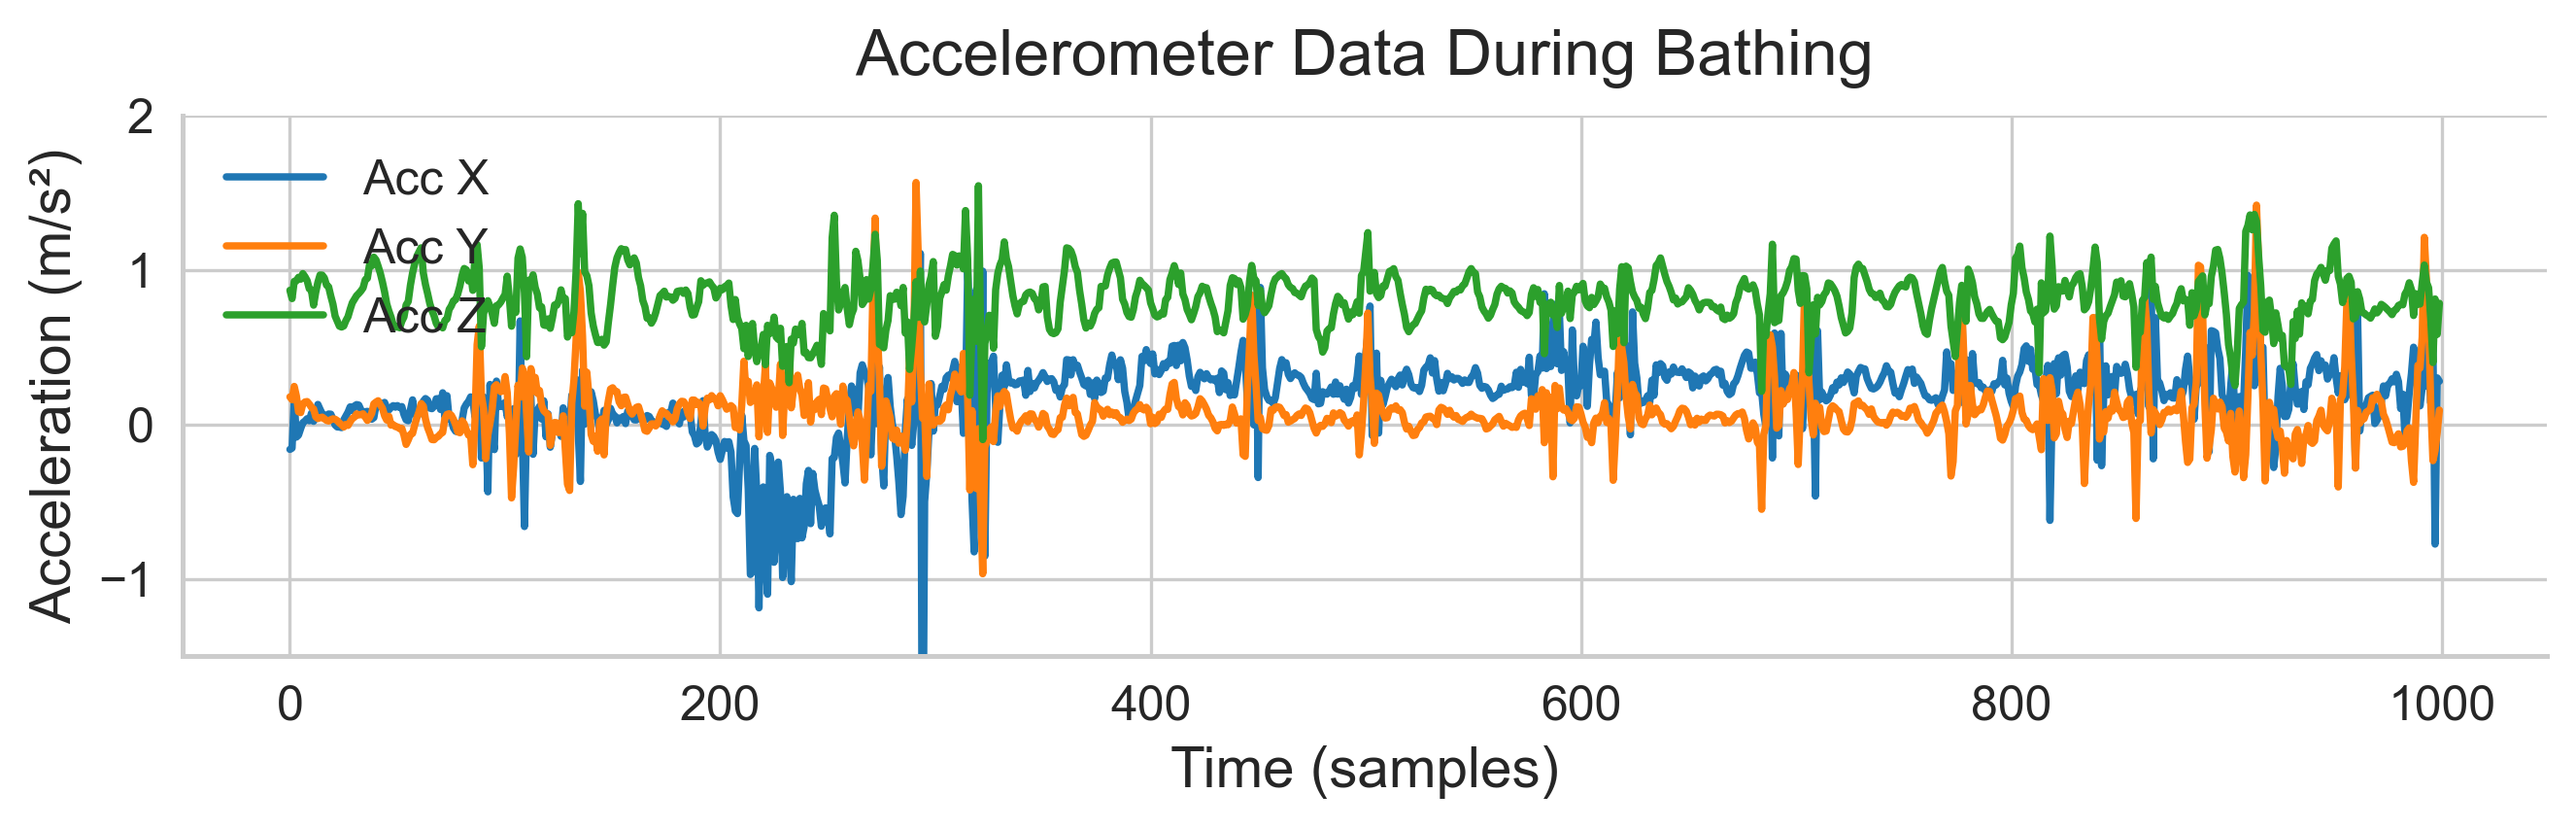

In [217]:
# 创建图形
fig, ax = plt.subplots(figsize=(9, 3), dpi=300)

time_range = np.arange(end - start)

# 绘制三轴加速度数据
ax.plot(time_range, bath_data_flat[start:end, 0], label='Acc X', linewidth=1.8, color='#1f77b4')
ax.plot(time_range, bath_data_flat[start:end, 1], label='Acc Y', linewidth=1.8, color='#ff7f0e')
ax.plot(time_range, bath_data_flat[start:end, 2], label='Acc Z', linewidth=1.8, color='#2ca02c')

# 设置标题和标签
ax.set_title('Accelerometer Data During Bathing', pad=10)
ax.set_ylabel('Acceleration (m/s²)')
ax.set_xlabel('Time (samples)')
ax.set_ylim(-1.5, 2)

# 设置图例
ax.legend(loc='upper left', frameon=False)

# 去除顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置背景
ax.set_facecolor('white')

# 自动布局
plt.tight_layout()

# 保存为高分辨率矢量图（可选）
# plt.savefig('acc_bathing.svg', format='svg', bbox_inches='tight')

# 显示图形
plt.show()

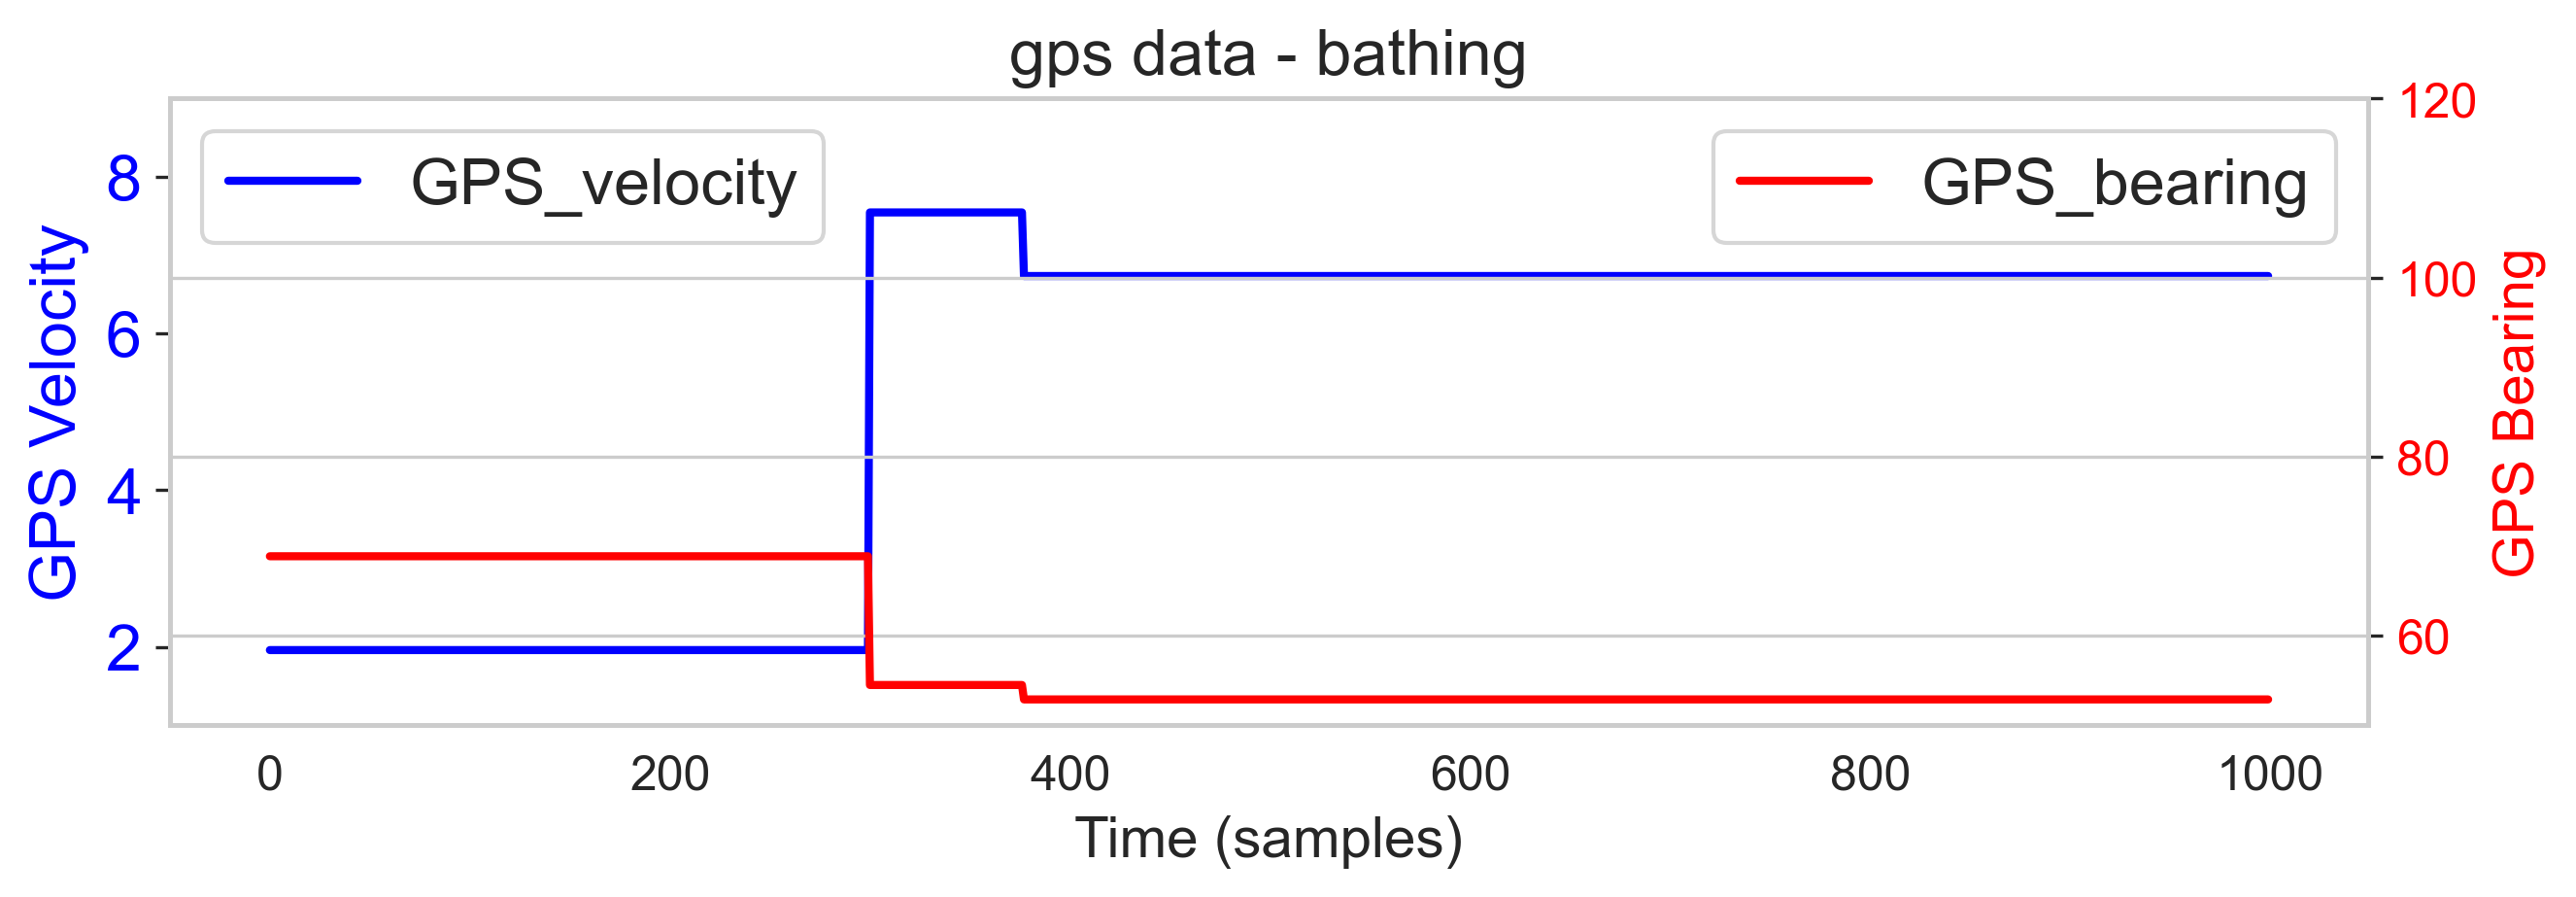

In [225]:
# 假设 bath_data_flat 是一个 NumPy 数组，并且 start 和 end 是有效的索引
plt.figure(figsize=(9, 3), dpi=300)

# 创建第一个 y 轴
ax1 = plt.gca()  # 显式获取主轴
ax1.plot(bath_data_flat[start:end, 6], label='GPS_velocity', color='b', linewidth=2)
ax1.set_ylabel('GPS Velocity', color='b', fontsize=16)
ax1.tick_params(axis='y', labelcolor='b', labelsize=16)
ax1.set_ylim(1, 9)

# 创建第二个 y 轴
ax2 = plt.gca().twinx()  # 创建共享 x 轴的第二个 y 轴
ax2.plot(bath_data_flat[start:end, 7], label='GPS_bearing', color='r', linewidth=2)
ax2.set_ylabel('GPS Bearing', color='r', fontsize=14)  # 设置右侧 y 轴的标签
ax2.tick_params(axis='y', labelcolor='r', labelsize=12)  # 设置右侧 y 轴刻度颜色
ax2.set_ylim(50, 120)  # 设置右侧 y 轴的范围

# 分别为两个轴添加图例
ax1.legend(loc='upper left', fontsize=16)
ax2.legend(loc='upper right', fontsize=16)

# 设置背景和网格
ax1.grid(False)
ax1.set_facecolor('white')

plt.title('gps data - bathing')
# 调整边距
plt.tight_layout()
ax1.set_xlabel('Time (samples)')

# 显示图形
plt.show()

In [219]:
flypass_label_idx = np.where(major_label == 4)[0]
flypass_data = data_b[flypass_label_idx, :, :]
# bath_data.shape
flypass_data_flat = np.concatenate(flypass_data.transpose(0,2,1), axis=0)
# bath_data_flat.shape

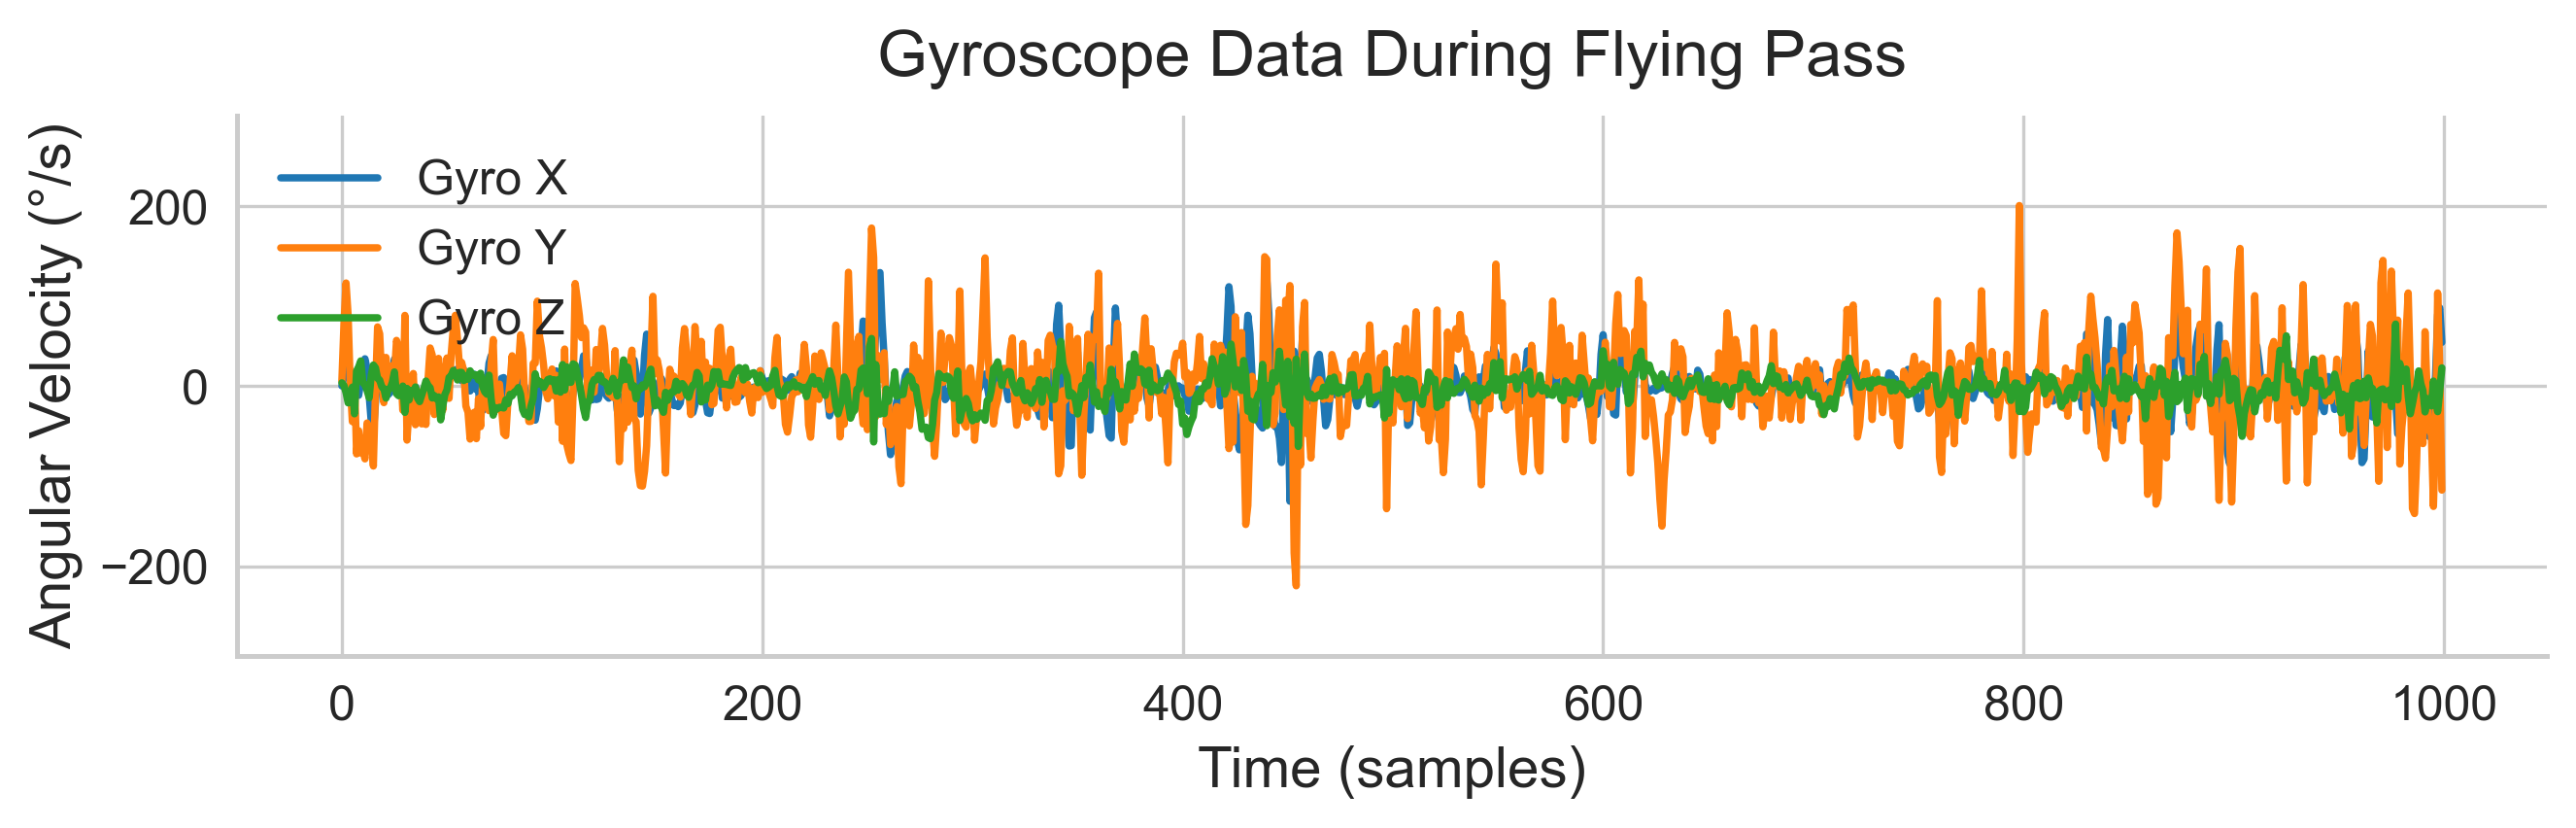

In [220]:
# 创建绘图
fig, ax = plt.subplots(figsize=(9, 3), dpi=300)

time_range = np.arange(end - start)

# 绘制三轴陀螺仪数据曲线
ax.plot(time_range, flypass_data_flat[start:end, 3], label='Gyro X', linewidth=1.8, color='#1f77b4')
ax.plot(time_range, flypass_data_flat[start:end, 4], label='Gyro Y', linewidth=1.8, color='#ff7f0e')
ax.plot(time_range, flypass_data_flat[start:end, 5], label='Gyro Z', linewidth=1.8, color='#2ca02c')

# 设置标题和轴标签
ax.set_title('Gyroscope Data During Flying Pass', pad=10)
ax.set_ylabel('Angular Velocity (°/s)')
ax.set_xlabel('Time (samples)')
ax.set_ylim(-300, 300)

# 设置图例
ax.legend(loc='upper left', frameon=False)

# 清理边框，使图更简洁
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置白色背景（默认）
ax.set_facecolor('white')

# 自动布局
plt.tight_layout()

# 可选保存为高质量矢量图
# plt.savefig('gyro_flypass.svg', format='svg', bbox_inches='tight')

# 显示图像
plt.show()

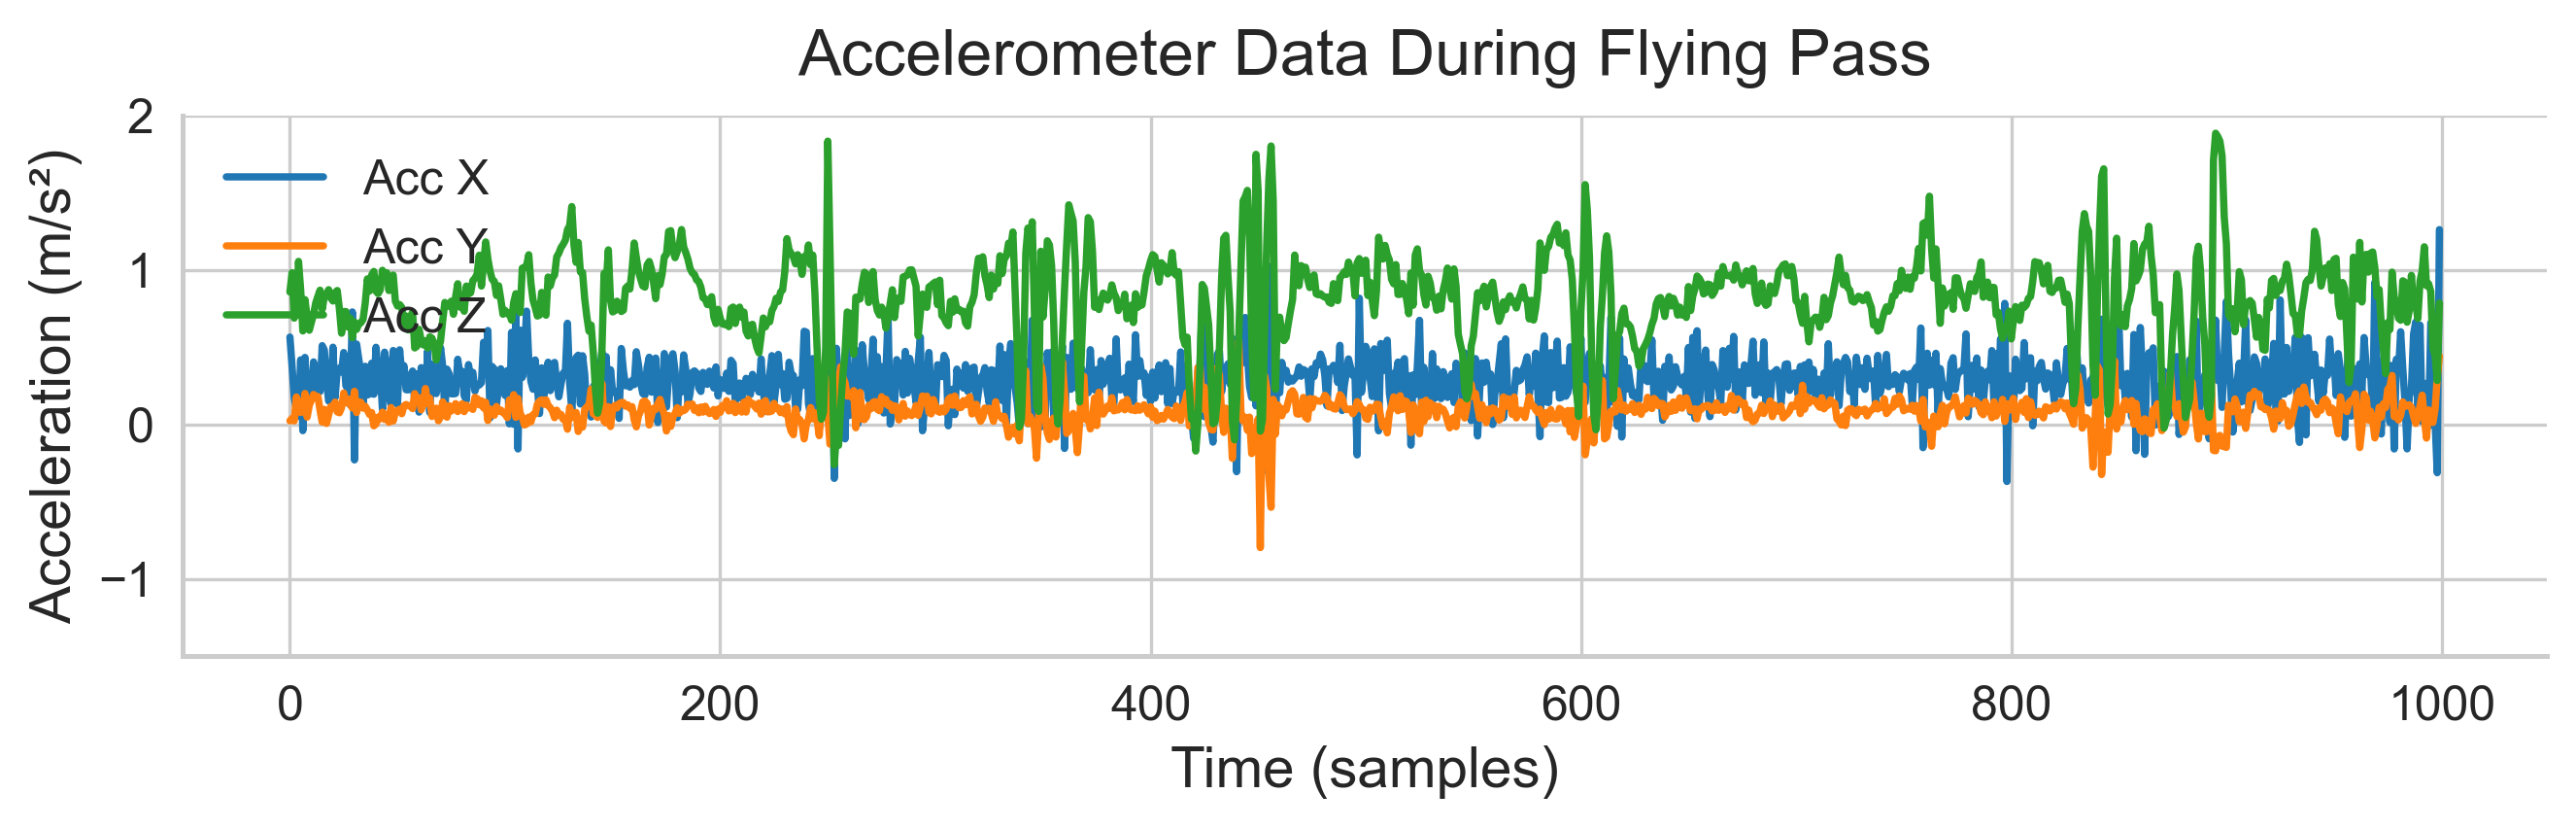

In [221]:
# 创建图像
fig, ax = plt.subplots(figsize=(9, 3), dpi=300)

time_range = np.arange(end - start)

# 绘制三轴加速度数据曲线
ax.plot(time_range, flypass_data_flat[start:end, 0], label='Acc X', linewidth=1.8, color='#1f77b4')
ax.plot(time_range, flypass_data_flat[start:end, 1], label='Acc Y', linewidth=1.8, color='#ff7f0e')
ax.plot(time_range, flypass_data_flat[start:end, 2], label='Acc Z', linewidth=1.8, color='#2ca02c')

# 设置标题与坐标轴标签
ax.set_title('Accelerometer Data During Flying Pass', pad=10)
ax.set_ylabel('Acceleration (m/s²)')
ax.set_xlabel('Time (samples)')
ax.set_ylim(-1.5, 2)

# 图例设置
ax.legend(loc='upper left', frameon=False)

# 去除多余边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置背景为白色
ax.set_facecolor('white')

# 自动调整布局
plt.tight_layout()

# 保存为矢量图（可选）
# plt.savefig('acc_flypass.svg', format='svg', bbox_inches='tight')

# 显示图形
plt.show()

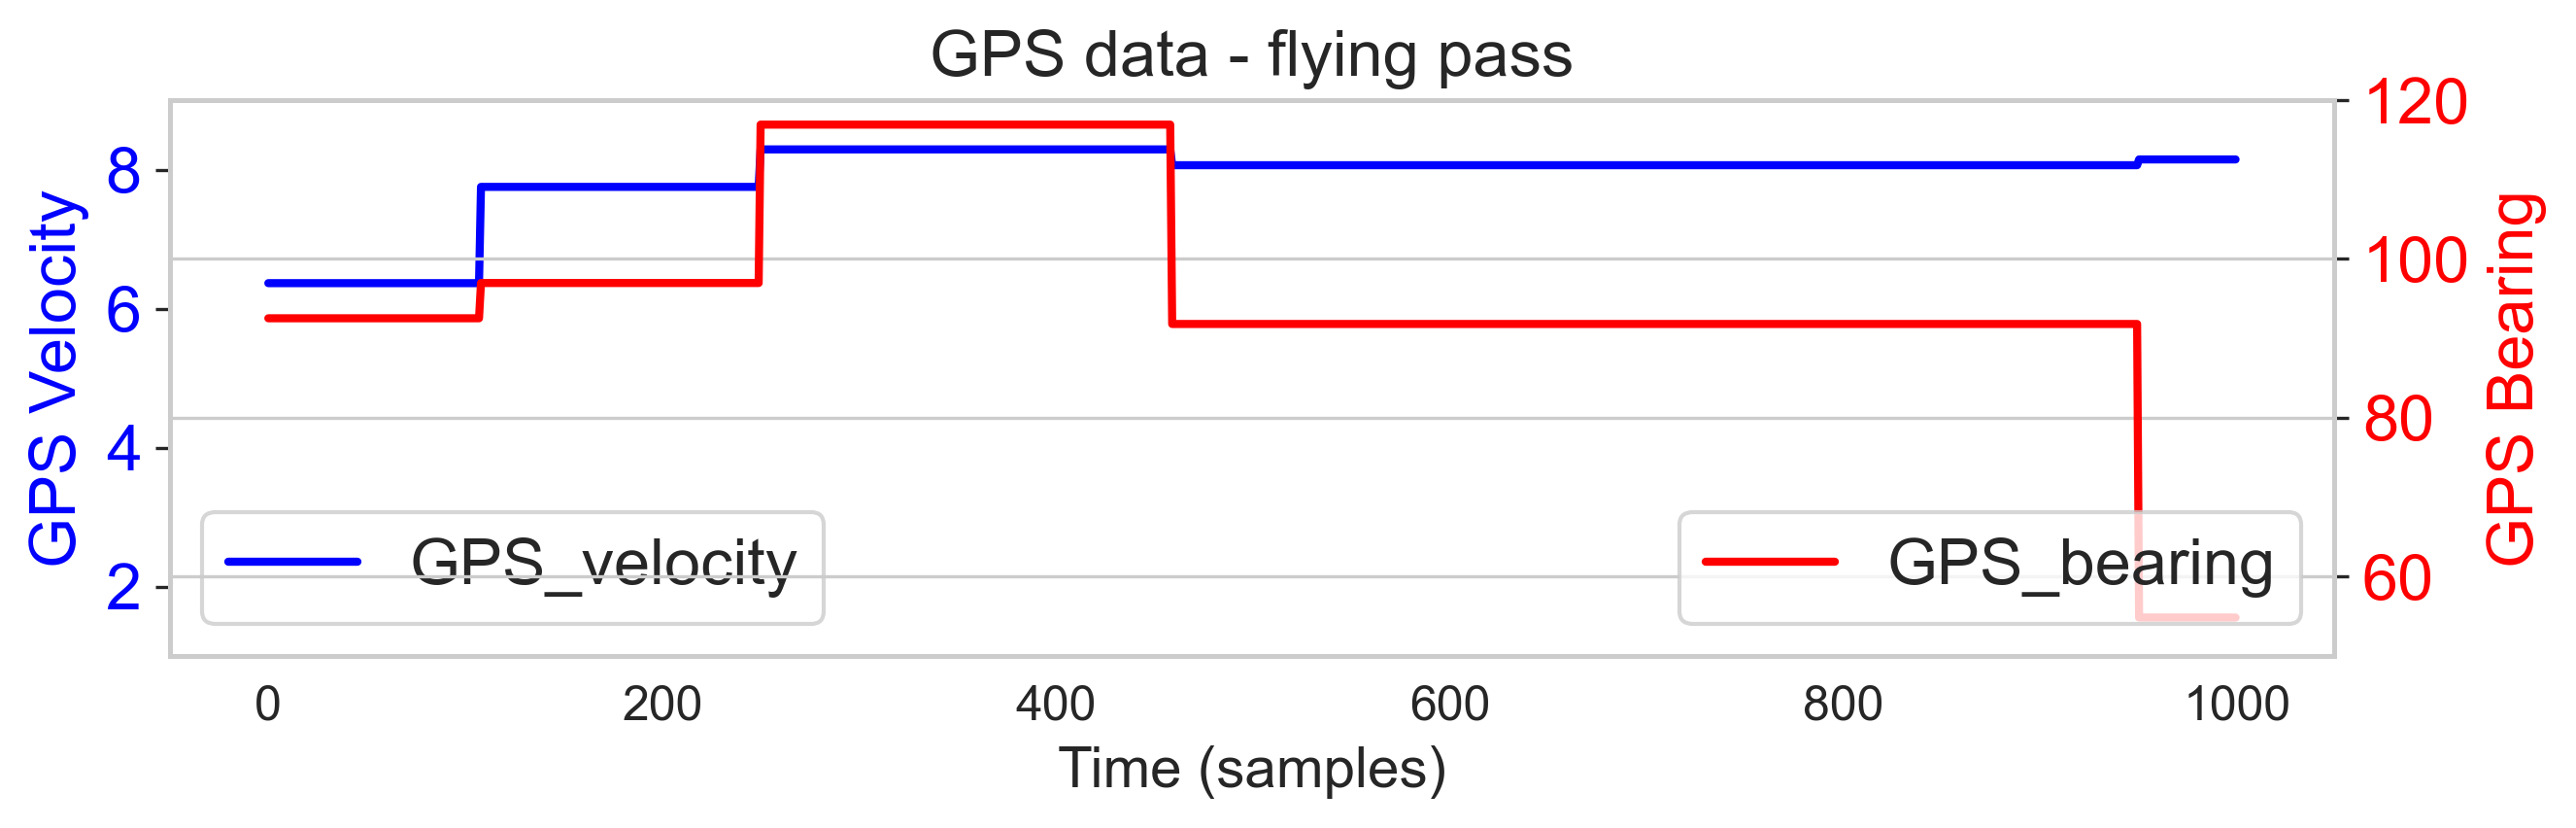

In [226]:
plt.figure(figsize=(9, 3), dpi=300)

# 创建第一个 y 轴
ax1 = plt.gca()  # 显式获取主轴
ax1.plot(flypass_data_flat[start:end, 6], label='GPS_velocity', color='b', linewidth=2)
ax1.set_ylabel('GPS Velocity', color='b', fontsize=16)
ax1.tick_params(axis='y', labelcolor='b', labelsize=16)
ax1.set_ylim(1, 9)

# 创建第二个 y 轴
ax2 = ax1.twinx()
ax2.plot(flypass_data_flat[start:end, 7], label='GPS_bearing', color='r', linewidth=2)
ax2.set_ylabel('GPS Bearing', color='r', fontsize=16)
ax2.tick_params(axis='y', labelcolor='r', labelsize=16)
ax2.set_ylim(50, 120)

# 分别为两个轴添加图例
ax1.legend(loc='lower left', fontsize=16)
ax2.legend(loc='lower right', fontsize=16)

# 设置背景和网格
ax1.grid(False)
ax1.set_facecolor('white')
ax1.set_xlabel('Time (samples)')

plt.title('GPS data - flying pass')
# 调整边距并保存
plt.tight_layout()
# plt.savefig('t.svg', format='svg', dpi=300)
plt.show()


# 坐标轴变换后的数据

In [96]:
selected_np = selected_df[columns].values
gyro_data = selected_np[:, 3:6]  # 取陀螺仪数据
acc_data = selected_np[:, 0:3]  # 取陀螺仪数据

# tmp_b = sliding_window(selected_np, len_sw, len_sw)
# # concatenate list
# data_b = np.transpose(tmp_b[:, :, :-1], (0, 2, 1))  # [B, Len, dim-1] -> [B, dim-1, Len]
# label_b = tmp_b[:, :, -1]  # [B, Len]
# 


In [97]:
gyro_data.shape

(371499, 3)

In [98]:
def rotation_matrix(roll, pitch, yaw):
    """生成旋转矩阵"""
    Rz = np.array([[np.cos(yaw), -np.sin(yaw), 0],
                   [np.sin(yaw), np.cos(yaw), 0],
                   [0, 0, 1]])
    
    Ry = np.array([[np.cos(pitch), 0, np.sin(pitch)],
                   [0, 1, 0],
                   [-np.sin(pitch), 0, np.cos(pitch)]])
    
    Rx = np.array([[1, 0, 0],
                   [0, np.cos(roll), -np.sin(roll)],
                   [0, np.sin(roll), np.cos(roll)]])
    
    # 组合旋转矩阵
    return Rz @ Ry @ Rx

def convert_acc_to_world(gyro_data, acc_data, dt):
    """
    将加速度数据从设备坐标系转换为世界坐标系
    :param gyro_data: 形状为(n, 3)的陀螺仪数据（角速度）
    :param acc_data: 形状为(n, 3)的加速度数据
    :param dt: 时间间隔（每个数据点之间的时间）
    :return: 形状为(n, 3)的世界坐标系中的加速度数据
    """
    n = gyro_data.shape[0]
    
    # 初始化姿态（滚转、俯仰、偏航）
    roll, pitch, yaw = 0.0, 0.0, 0.0
    world_acc_data = np.zeros_like(acc_data)  # 创建一个与acc_data相同形状的数组用于存储结果

    for i in range(n):
        # 积分得到当前角度（滚转、俯仰、偏航）
        roll += gyro_data[i, 0] * dt
        pitch += gyro_data[i, 1] * dt
        yaw += gyro_data[i, 2] * dt
        
        # 生成旋转矩阵
        R = rotation_matrix(roll, pitch, yaw)
        
        # 将加速度数据转换为世界坐标系
        world_acc_data[i] = acc_data[i] @ R.T  # 转置以进行矩阵乘法

    return world_acc_data

In [99]:
# n = 1000
dt = 0.04  # 时间间隔
# gyro_data = np.random.rand(n, 3) * 0.1  # 生成随机角速度数据
# acc_data = np.random.rand(n, 3)  # 生成随机加速度数据

# 转换加速度数据到世界坐标系
world_acc_data = convert_acc_to_world(gyro_data, acc_data, dt)

# print("World Coordinate Acceleration Data (First 5 Points):")
# print(world_acc_data[:5])

In [100]:
selected_np[:, 0:3] = world_acc_data
selected_np[:, 3:6] = gyro_data
tmp_b = sliding_window(selected_np, len_sw, len_sw)
# concatenate list
data_b = np.transpose(tmp_b[:, :, :-1], (0, 2, 1))  # [B, Len, dim-1] -> [B, dim-1, Len]
label_b = tmp_b[:, :, -1]  # [B, Len]
major_label = majority_value(label_b)
bath_label_idx = np.where(major_label == 2)[0]
bath_data = data_b[bath_label_idx, :, :]
bath_data_flat = np.concatenate(bath_data.transpose(0,2,1), axis=0)


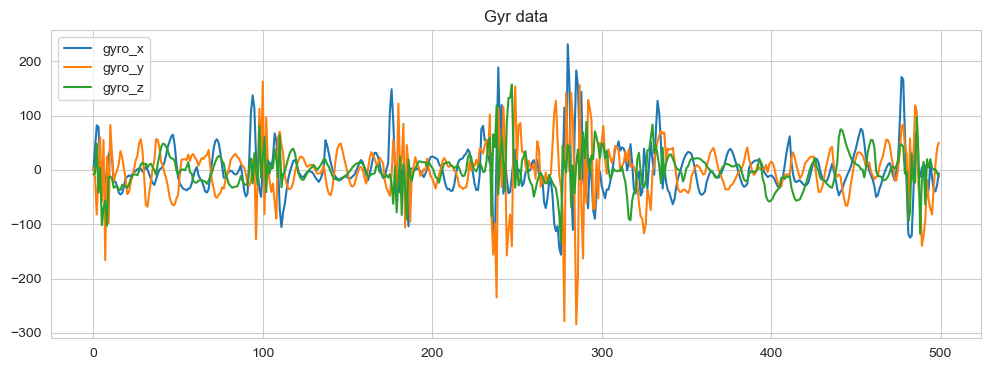

In [112]:
start = 1500
end = 2000
plt.figure(figsize=(12,4))
plt.plot(np.arange(end-start), bath_data_flat[start:end, 3], label='gyro_x')
plt.plot(np.arange(end-start), bath_data_flat[start:end, 4], label='gyro_y')
plt.plot(np.arange(end-start), bath_data_flat[start:end, 5], label='gyro_z')
plt.title('Gyr data')
# plt.ylim(-10, 10)  # 限制Y轴范围
plt.legend()
plt.show()

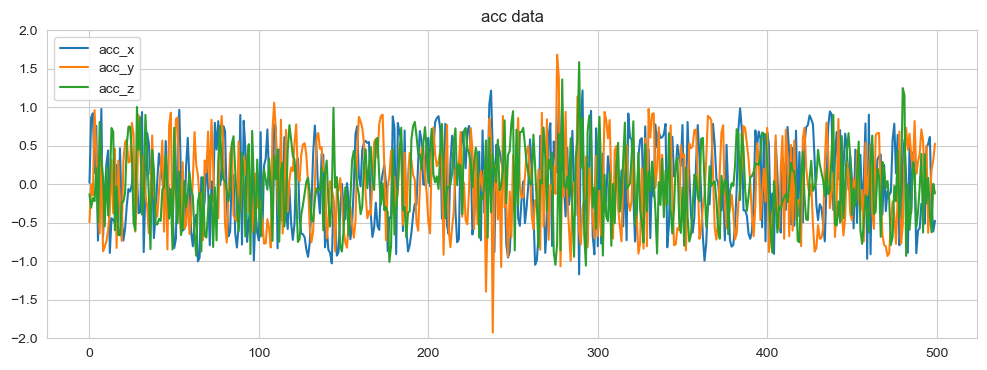

In [113]:
plt.figure(figsize=(12,4))
plt.plot(np.arange(end-start), bath_data_flat[start:end, 0], label='acc_x')
plt.plot(np.arange(end-start), bath_data_flat[start:end, 1], label='acc_y')
plt.plot(np.arange(end-start), bath_data_flat[start:end, 2], label='acc_z')
plt.title('acc data')
plt.ylim(-2, 2)  # 限制Y轴范围
plt.legend()
plt.show()

In [114]:
flypass_label_idx = np.where(major_label == 4)[0]
flypass_data = data_b[flypass_label_idx, :, :]
# bath_data.shape
flypass_data_flat = np.concatenate(flypass_data.transpose(0,2,1), axis=0)
# bath_data_flat.shape

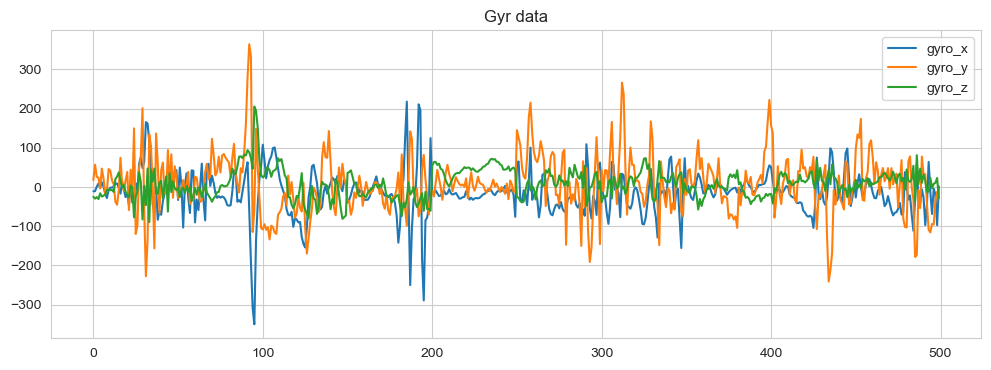

In [115]:
plt.figure(figsize=(12,4))
plt.plot(np.arange(end-start), flypass_data_flat[start:end, 3], label='gyro_x')
plt.plot(np.arange(end-start), flypass_data_flat[start:end, 4], label='gyro_y')
plt.plot(np.arange(end-start), flypass_data_flat[start:end, 5], label='gyro_z')
plt.title('Gyr data')
# plt.ylim(-10, 10)  # 限制Y轴范围
plt.legend()
plt.show()

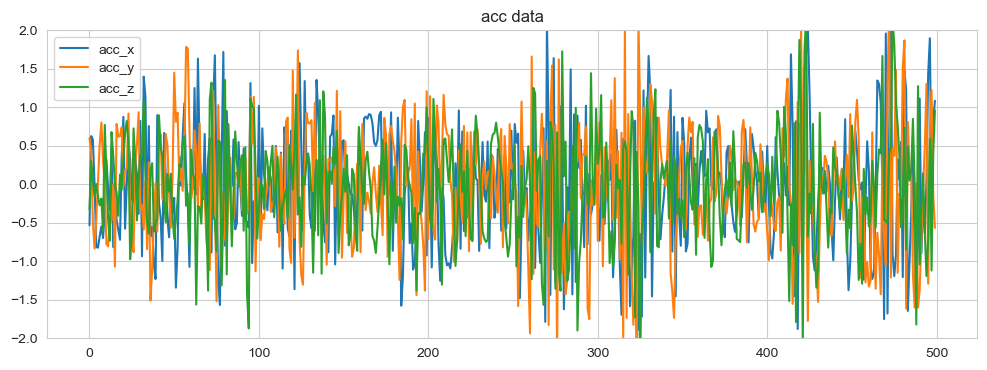

In [118]:
plt.figure(figsize=(12,4))
plt.plot(np.arange(end-start), flypass_data_flat[start:end, 0], label='acc_x')
plt.plot(np.arange(end-start), flypass_data_flat[start:end, 1], label='acc_y')
plt.plot(np.arange(end-start), flypass_data_flat[start:end, 2], label='acc_z')
plt.title('acc data')
plt.ylim(-2, 2)  # 限制Y轴范围
plt.legend()
plt.show()